In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.utils.class_weight import compute_class_weight

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---------------------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------------------

IMG_SIZE    = (56, 56)      # Target size (MobileNetV2 requires min 32x32)
BATCH_SIZE  = 32
NUM_CLASSES = 9

CLASS_NAMES = [
    'Center', 'Donut', 'Edge-Loc', 'Edge-Ring',
    'Loc', 'Near-Full', 'Random', 'Scratch', 'None'
]

# Dataset path
DATASET_PATH = '/content/drive/MyDrive/LSWMD.pkl'


# ---------------------------------------------------------------------------
# Preprocessing
# ---------------------------------------------------------------------------

def preprocess_wafer_map(wafer_map, target_size=(56, 56)): # Assuming IMG_SIZE is defined or passed
    """
    Preprocess a single wafer map:
    - Cast to float32
    - Resize to target_size
    - Convert from greyscale to RGB
    """
    img = tf.cast(wafer_map, tf.float32)
    if len(img.shape) == 2:
        img = tf.expand_dims(img, axis=-1)

    img = tf.image.resize(img, target_size)

    img = tf.image.grayscale_to_rgb(img)

    return img


def create_tf_dataset(images, labels, batch_size=32, augment=False, shuffle=False): # Assuming BATCH_SIZE and SEED are defined or passed
    dataset = tf.data.Dataset.from_tensor_slices((images, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(images), seed=42) # Using SEED

    dataset = dataset.map(
        lambda x, y: (tf.cast(x, tf.float32), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    # Training set data augmentation
    if augment:
        augmentation = keras.Sequential([
            layers.RandomFlip('horizontal_and_vertical'),
            layers.RandomRotation(0.1),
        ])
        dataset = dataset.map(
            lambda x, y: (augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

with open(DATASET_PATH, 'rb') as f:
    df = pd.read_pickle(f)

# Filter out samples with unknown labels
df = df[df['failureType'] != 'none']

# Label encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform([x[0] for x in df['failureType']])
CLASS_NAMES = list(le.classes_)
NUM_CLASSES = len(CLASS_NAMES)

# Preprocess all wafer maps to a consistent size before creating the X array
X = np.array([preprocess_wafer_map(wm, target_size=IMG_SIZE).numpy() for wm in df['waferMap'].values])
y = df['label'].values

# Split train/val/test
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Classes: {NUM_CLASSES}")
print(f"Train distribution: {np.bincount(y_train)}")

TensorFlow version: 2.20.0
GPU available: True


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Train: (17863, 56, 56, 3), Val: (3828, 56, 56, 3), Test: (3828, 56, 56, 3)
Classes: 8
Train distribution: [3006  389 3632 6776 2515  104  606  835]


In [ ]:
train_ds = create_tf_dataset(X_train, y_train, augment=True,  shuffle=True)
val_ds   = create_tf_dataset(X_val,   y_val,   augment=False, shuffle=False)
test_ds  = create_tf_dataset(X_test,  y_test,  augment=False, shuffle=False)

# Class weights to handle class imbalance
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights_array))
print("Class weights:", {CLASS_NAMES[k]: round(v, 2) for k, v in class_weight_dict.items()})


Class weights: {np.str_('Center'): np.float64(0.74), np.str_('Donut'): np.float64(5.74), np.str_('Edge-Loc'): np.float64(0.61), np.str_('Edge-Ring'): np.float64(0.33), np.str_('Loc'): np.float64(0.89), np.str_('Near-full'): np.float64(21.47), np.str_('Random'): np.float64(3.68), np.str_('Scratch'): np.float64(2.67)}


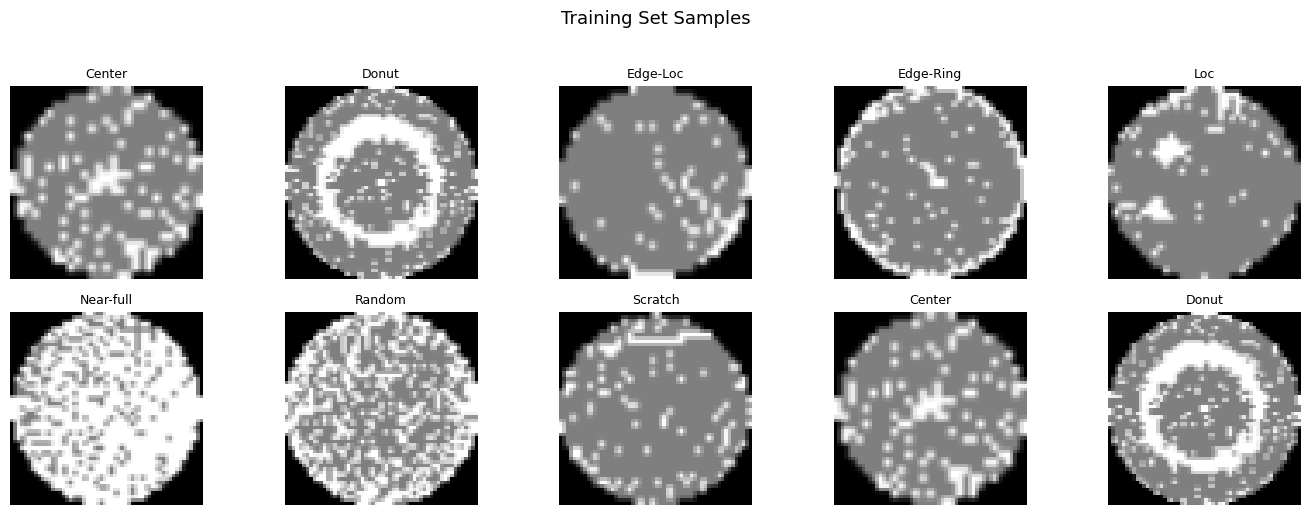

In [ ]:
# Visualisation
fig, axes = plt.subplots(2, 5, figsize=(14, 5))
for i, ax in enumerate(axes.flat):
    idx = np.where(y_train == i % NUM_CLASSES)[0][0]

    # Normalisation
    img = X_train[idx] / 2.0

    ax.imshow(img, cmap='Greys', interpolation='nearest', vmin=0, vmax=1)
    ax.set_title(CLASS_NAMES[y_train[idx]], fontsize=9)
    ax.axis('off')

plt.suptitle('Training Set Samples', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
def build_model(num_classes=NUM_CLASSES, img_size=IMG_SIZE, trainable_base=False):
    """
    Costruisce il modello MobileNetV2 con classification head custom.

    Args:
        num_classes: numero di classi
        img_size: tuple (H, W)
        trainable_base: se True, la base è addestrabile (usato nella fase 2)
    """
    # Pre-trained model
    base_model = keras.applications.MobileNetV2(
        input_shape=(*img_size, 3),
        include_top=False,      # Remove ImageNet classifier
        weights='imagenet'      # Weights pre-trained on ImageNet
    )
    base_model.trainable = trainable_base

    inputs = keras.Input(shape=(*img_size, 3))

    # MobileNetV2 specific preprocessing: pixels must be in [-1, 1]
    x = keras.applications.mobilenet_v2.preprocess_input(inputs)

    # Feature extraction
    x = base_model(x, training=False)

    # Global Average Pooling: riduce (7, 7, 1280) -> (1280,)
    x = layers.GlobalAveragePooling2D()(x)

    # Regularisation
    x = layers.Dropout(0.3)(x)

    # Classifier output
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='MobileNetV2_FineTuned')
    return model, base_model


model, base_model = build_model(trainable_base=False)
model.summary()

/tmp/ipykernel_5338/3795136034.py:11: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_FineTuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 56, 56, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 56, 56, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 56, 56, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │        10,248 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,268,232 (8.65 MB)

 Trainable params: 10,248 (40.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
EPOCHS_PHASE1 = 15
LR_PHASE1     = 1e-3

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_PHASE1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, verbose=1
    )
]

history_phase1 = model.fit(
    train_ds,
    epochs=EPOCHS_PHASE1,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase1,
    verbose=1
)

Epoch 1/15
559/559 ━━━━━━━━━━━━━━━━━━━━ 66s 83ms/step - accuracy: 0.3856 - loss: 1.6888 - val_accuracy: 0.4974 - val_loss: 1.2881 - learning_rate: 0.0010
Epoch 2/15
559/559 ━━━━━━━━━━━━━━━━━━━━ 24s 42ms/step - accuracy: 0.4852 - loss: 1.3614 - val_accuracy: 0.4370 - val_loss: 1.4612 - learning_rate: 0.0010
Epoch 3/15
559/559 ━━━━━━━━━━━━━━━━━━━━ 22s 40ms/step - accuracy: 0.5075 - loss: 1.2991 - val_accuracy: 0.4122 - val_loss: 1.4534 - learning_rate: 0.0010
Epoch 4/15
558/559 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5085 - loss: 1.2463
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
559/559 ━━━━━━━━━━━━━━━━━━━━ 22s 39ms/step - accuracy: 0.5140 - loss: 1.2525 - val_accuracy: 0.4718 - val_loss: 1.4051 - learning_rate: 0.0010
Epoch 5/15
559/559 ━━━━━━━━━━━━━━━━━━━━ 23s 40ms/step - accuracy: 0.5225 - loss: 1.2486 - val_accuracy: 0.5653 - val_loss: 1.1859 - learning_rate: 5.0000e-04
Epoch 6/15
559/559 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0.5369 -

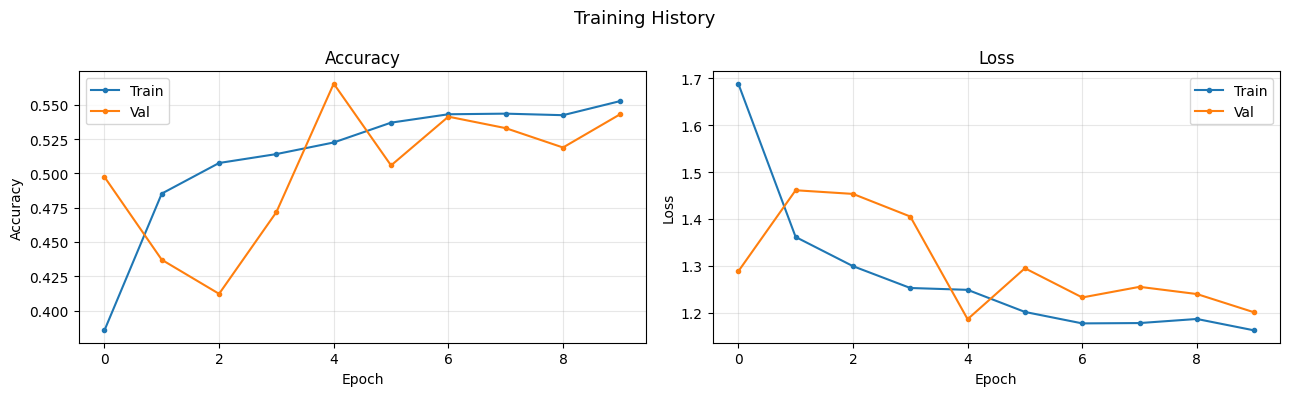

In [ ]:
def plot_history(history, title='Training History'):
    """Plot accuracy and loss for validation and training"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    # Accuracy
    ax1.plot(history.history['accuracy'],     label='Train', marker='o', markersize=3)
    ax1.plot(history.history['val_accuracy'], label='Val',   marker='o', markersize=3)
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Loss
    ax2.plot(history.history['loss'],     label='Train', marker='o', markersize=3)
    ax2.plot(history.history['val_loss'], label='Val',   marker='o', markersize=3)
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

plot_history(history_phase1)

In [8]:
EPOCHS_PHASE2  = 20
LR_PHASE2      = 1e-5
FINE_TUNE_FROM = 100

base_model.trainable = True

# Freeze initial layers (generic features, edges, textures...)
for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

# Count trainable layers
n_trainable = sum(1 for l in base_model.layers if l.trainable)
print(f"Layer scongelati nella base: {n_trainable} / {len(base_model.layers)}")

# Recompile with lower learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_PHASE2),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=4, verbose=1
    )
]

history_phase2 = model.fit(
    train_ds,
    epochs=EPOCHS_PHASE2,
    validation_data=val_ds,
    class_weight=class_weight_dict,
    callbacks=callbacks_phase2,
    verbose=1
)

Layer scongelati nella base: 54 / 154
Epoch 1/20
559/559 ━━━━━━━━━━━━━━━━━━━━ 63s 73ms/step - accuracy: 0.2768 - loss: 3.1589 - val_accuracy: 0.0350 - val_loss: 2.5741 - learning_rate: 1.0000e-05
Epoch 2/20
559/559 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.4121 - loss: 1.8728 - val_accuracy: 0.1236 - val_loss: 2.1436 - learning_rate: 1.0000e-05
Epoch 3/20
559/559 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.4696 - loss: 1.5650 - val_accuracy: 0.0909 - val_loss: 2.1539 - learning_rate: 1.0000e-05
Epoch 4/20
559/559 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.4909 - loss: 1.5050 - val_accuracy: 0.1473 - val_loss: 2.3752 - learning_rate: 1.0000e-05
Epoch 5/20
559/559 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.5186 - loss: 1.3681 - val_accuracy: 0.1839 - val_loss: 2.0568 - learning_rate: 1.0000e-05
Epoch 6/20
559/559 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.5392 - loss: 1.2838 - val_accuracy: 0.2586 - val_loss: 1.9324 - learning_rate: 1.0000e-05
Epoch 7/20
559

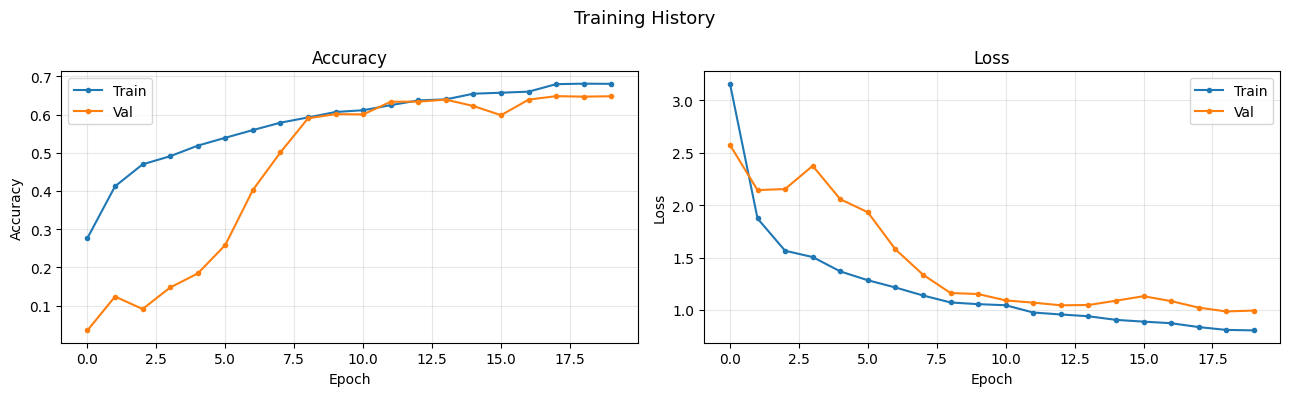

In [9]:
plot_history(history_phase2)


In [10]:
def compute_metrics(y_true, y_pred, model_name='Model'):
    metrics = {
        'Accuracy':          accuracy_score(y_true, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
        'Macro Precision':   precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro Recall':      recall_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro F1':          f1_score(y_true, y_pred, average='macro', zero_division=0),
    }

    print(f"\n{'=' * 50}")
    print(f"  Metrics — {model_name}")
    print(f"{'=' * 50}")
    for name, value in metrics.items():
        print(f"  {name:<22}: {value:.4f}")
    print(f"{'=' * 50}")

    return metrics


def get_predictions(model, dataset):
    y_pred_proba = model.predict(dataset, verbose=0)
    y_pred       = np.argmax(y_pred_proba, axis=1)
    return y_pred, y_pred_proba


# Test set predictions
y_pred_ft, y_pred_proba_ft = get_predictions(model, test_ds)

# Fine-tuned model metrics
metrics_ft = compute_metrics(y_test, y_pred_ft, model_name='MobileNetV2 Fine-Tuned')


  Metrics — MobileNetV2 Fine-Tuned
  Accuracy              : 0.6560
  Balanced Accuracy     : 0.6865
  Macro Precision       : 0.5220
  Macro Recall          : 0.6865
  Macro F1              : 0.5295


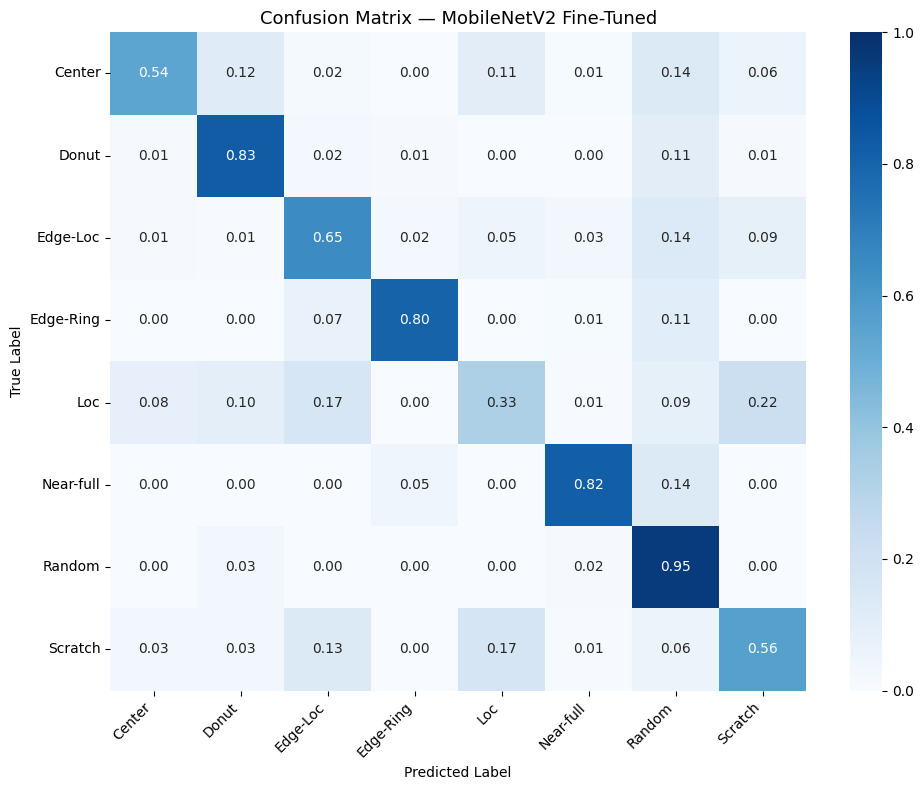

In [11]:
def plot_confusion_matrix(y_true, y_pred, class_names, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        vmin=0, vmax=1
    )
    plt.title(title, fontsize=13)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, y_pred_ft, CLASS_NAMES, 'Confusion Matrix — MobileNetV2 Fine-Tuned')

In [12]:
print("Classification Report — MobileNetV2 Fine-Tuned")
print(classification_report(y_test, y_pred_ft, target_names=CLASS_NAMES, zero_division=0))

Classification Report — MobileNetV2 Fine-Tuned
              precision    recall  f1-score   support

      Center       0.85      0.54      0.66       644
       Donut       0.32      0.83      0.46        83
    Edge-Loc       0.68      0.65      0.67       779
   Edge-Ring       0.98      0.80      0.88      1452
         Loc       0.56      0.33      0.42       539
   Near-full       0.26      0.82      0.39        22
      Random       0.23      0.95      0.36       130
     Scratch       0.30      0.56      0.40       179

    accuracy                           0.66      3828
   macro avg       0.52      0.69      0.53      3828
weighted avg       0.76      0.66      0.68      3828

